## A Transformer Built from Scratch

A Transformer encoder-decoder for English-French translation, implemented from scratch in PyTorch 

**Dataset:** ~175K English-French sentence pairs, filtered to ≤20 tokens.

**Includes:** full encoder-decoder architecture, training with label smoothing and LR warmup, greedy and beam search decoding (batched for fast inference), BLEU evaluation, attention visualization, and qualitative error analysis.

In [1]:
!pip install sacrebleu
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import sacrebleu
from tqdm.auto import tqdm
import pickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00


In [2]:
df = pd.read_csv('/kaggle/input/datasets/devicharith/language-translation-englishfrench/eng_-french.csv')
df.columns = ["english", "french"]

In [3]:
df.sample(5)

,english,french
82362,I can't just leave you here.,Je ne peux pas simplement vous laisser ici.
90722,I'll do it if you don't mind.,"Je le ferai, si ça ne vous dérange pas."
144169,I play bass guitar in a guitar ensemble.,Je joue de la basse dans un ensemble de guitares.
138814,They went to the public swimming pool.,Ils sont allés à la piscine publique.
53308,Have you had dinner yet?,As-tu déjà dîné ?


In [4]:
print(len(df))

175621


In [5]:
def preprocess(text):
    text = text.lower()

    # Separate punctuation
    text = re.sub(r'([.!?,;:])', r' \1 ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df["english"] = df["english"].apply(preprocess)
df["french"] = df["french"].apply(preprocess)

In [6]:
df.isnull().sum(), df.duplicated().sum()

(english    0
 french     0
 dtype: int64,
 np.int64(197))

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum(), len(df)

(np.int64(0), 175424)

## **Exploratory Data Analysis (EDA)**

In [9]:
df["en_len"] = df["english"].astype(str).apply(lambda x: len(x.split()))
df["fr_len"] = df["french"].astype(str).apply(lambda x: len(x.split()))

In [10]:
print("\nEnglish Length Statistics")
print(df["en_len"].describe())

print("\nFrench Length Statistics")
print(df["fr_len"].describe())


English Length Statistics
count    175424.000000
mean          7.233987
std           2.583596
min           2.000000
25%           5.000000
50%           7.000000
75%           8.000000
max          48.000000
Name: en_len, dtype: float64

French Length Statistics
count    175424.000000
mean          7.602785
std           2.933848
min           2.000000
25%           6.000000
50%           7.000000
75%           9.000000
max          59.000000
Name: fr_len, dtype: float64


In [11]:
print("\nEnglish")
print(df["en_len"].quantile([0.50, 0.90, 0.95, 0.99]))

print("\nFrench")
print(df["fr_len"].quantile([0.50, 0.90, 0.95, 0.99]))


English
0.50     7.0
0.90    10.0
0.95    12.0
0.99    16.0
Name: en_len, dtype: float64

French
0.50     7.0
0.90    11.0
0.95    13.0
0.99    17.0
Name: fr_len, dtype: float64


In [12]:
print("Max English Length:", df["en_len"].max())
print("Max French Length:", df["fr_len"].max())

Max English Length: 48
Max French Length: 59


In [13]:
eng_counter = Counter()
fr_counter = Counter()

for sent in df["english"]:
    eng_counter.update(sent.lower().split())

for sent in df["french"]:
    fr_counter.update(sent.lower().split())

eng_vocab_size = len(eng_counter)
fr_vocab_size = len(fr_counter)

print("VOCABULARY STATISTICS")
print("=" * 30)

print("English Vocabulary Size:", eng_vocab_size)
print("French Vocabulary Size:", fr_vocab_size)

VOCABULARY STATISTICS
English Vocabulary Size: 14980
French Vocabulary Size: 29695


In [14]:
eng_singletons = sum(1 for _, count in eng_counter.items() if count == 1)

fr_singletons = sum(1 for _, count in fr_counter.items() if count == 1)

print("SINGLETON WORDS")
print("\n")

print(
    f"English singleton words: "
    f"{eng_singletons} "
    f"({eng_singletons/eng_vocab_size:.2%})"
)

print(
    f"French singleton words: "
    f"{fr_singletons} "
    f"({fr_singletons/fr_vocab_size:.2%})"
)


SINGLETON WORDS


English singleton words: 4834 (32.27%)
French singleton words: 11592 (39.04%)


In [15]:
eng_rare = sum(1 for _, count in eng_counter.items() if count <= 2)

fr_rare = sum(1 for _, count in fr_counter.items() if count <= 2)

print("WORDS OCCURRING <= 2 TIMES")
print("\n")

print(
    f"English: {eng_rare} "
    f"({eng_rare/eng_vocab_size:.2%})"
)

print(
    f"French: {fr_rare} "
    f"({fr_rare/fr_vocab_size:.2%})"
)

WORDS OCCURRING <= 2 TIMES


English: 6930 (46.26%)
French: 16069 (54.11%)


In [16]:
TOP_FR = 15000

total_fr_tokens = sum(fr_counter.values())

top_fr_tokens = sum(
    count
    for _, count in fr_counter.most_common(TOP_FR)
)

fr_coverage = top_fr_tokens / total_fr_tokens

print("FRENCH VOCAB COVERAGE")
print("=" * 30)

print(f"Top {TOP_FR:,} words coverage: {fr_coverage:.4%}")

TOP_ENG = 15000

total_eng_tokens = sum(eng_counter.values())

top_eng_tokens = sum(
    count
    for _, count in eng_counter.most_common(TOP_ENG)
)

eng_coverage = top_eng_tokens / total_eng_tokens

print(f"Top {TOP_ENG:,} words coverage: {eng_coverage:.4%}")

FRENCH VOCAB COVERAGE
Top 15,000 words coverage: 98.6655%
Top 15,000 words coverage: 100.0000%


In [17]:
for k in [5000, 10000, 15000, 20000]:
    coverage = (
        sum(c for _, c in fr_counter.most_common(k))
        / sum(fr_counter.values())
    )

    print(f"Top {k:>5} French words -> {coverage:.4%}")

Top  5000 French words -> 94.8437%
Top 10000 French words -> 97.5498%
Top 15000 French words -> 98.6655%
Top 20000 French words -> 99.2731%


In [18]:
for k in [5000, 10000, 12000, 15000]:
    coverage = (
        sum(c for _, c in eng_counter.most_common(k))
        / sum(eng_counter.values())
    )
    print(f"Top {k:>5} English words -> {coverage:.4%}")

Top  5000 English words -> 98.2896%
Top 10000 English words -> 99.5961%
Top 12000 English words -> 99.7652%
Top 15000 English words -> 100.0000%


## **EDA Summary**

### **Dataset Overview**

This dataset has a total of 175K English–French sentence pairs so it seems like a decent enough amount of training data for a machine translation task.

### **Sentence Length Analysis**

Most sentences in the dataset are quite short.

* Average English sentence length: **7.23 words**
* Average French sentence length: **7.60 words**
* 95% of English sentences are **12 words or shorter**
* 95% of French sentences are **13 words or shorter**
* 99% of the sentences in both languages are shorter than **17 words**

Very few sentences from the context are extremely longer (the longest ones) though. Given these statistics, using a maximum sequence length of 20 tokens should cover almost the whole dataset whilst avoiding wasteful padding.

---

### **Vocabulary Analysis**

The dataset contains:

* **14,980 unique English words**
* **29,695 unique French words**

The English vocabulary is almost half the size of the French vocabulary. This is to be expected as French has more variations of words with its conjugations, gender forms and other grammar changes.

---

### **Rare Words**

A large number of words appear very rarely in the dataset.

Words appearing only once:

* English: **32.27%**
* French: **39.04%**

Words appearing at most twice:

* English: **46.26%**
* French: **54.11%**

That is, almost half of the vocabulary is made up of words that occur very infrequently. Since the model sees these words only one or two times, it is difficult to learn useful representations for them.

---

### **Vocabulary Coverage**

To determine how many words to keep in the vocabulary, I looked at how much of the dataset is covered by the most frequent words.

#### **English**

| Top Words | Coverage |
| --------- | -------- |
| 5,000     | 98.29%   |
| 10,000    | 99.60%   |
| 12,000    | 99.77%   |

#### **French**

| Top Words | Coverage |
| --------- | -------- |
| 5,000     | 94.84%   |
| 10,000    | 97.55%   |
| 15,000    | 98.67%   |

The results show that a few of the frequent words are responsible for almost all the words in the data set.

---

### **Final Decision**

Based on the length distribution, rare-word analysis, and vocabulary coverage:

* **English vocabulary size = 10,000**
* **French vocabulary size = 15,000**
* **Maximum sequence length = 20**


In [19]:
MAX_LEN = 20

df = df[(df["en_len"] <= MAX_LEN) & (df["fr_len"] <= MAX_LEN)]

print("Remaining sentence pairs:", len(df))

Remaining sentence pairs: 174842


In [20]:
df.drop(columns=["en_len", "fr_len"], inplace=True)

In [21]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

In [22]:
len(train_df), len(val_df), len(test_df)

(139873, 17484, 17485)

In [23]:
english_counter = Counter()

for sentence in train_df["english"]:
    english_counter.update(sentence.lower().split())

TOP_ENG = 10000
english_vocab = {
    "<pad>": 0,
    "<unk>": 1
}

for word, _ in english_counter.most_common(TOP_ENG):
    english_vocab[word] = len(english_vocab)

print("English vocab size:", len(english_vocab))

English vocab size: 10002


In [24]:
french_counter = Counter()

for sentence in train_df["french"]:
    french_counter.update(sentence.lower().split())

TOP_FR = 15000
french_vocab = {
    "<pad>": 0,
    "<unk>": 1,
    "<sos>": 2,
    "<eos>": 3
}

for word, _ in french_counter.most_common(TOP_FR):
    french_vocab[word] = len(french_vocab)

print("French vocab size:", len(french_vocab))

French vocab size: 15004


In [25]:
def english_word_to_idx(sentence):
    return [english_vocab.get(word, english_vocab["<unk>"])for word in sentence.split()]

def french_word_to_idx(sentence):
    return [french_vocab.get(word, french_vocab["<unk>"])for word in sentence.split()]

In [26]:
for split_df in [train_df, val_df, test_df]:
    split_df['french_for_ids'] = '<sos> ' + split_df['french'] + ' <eos>'
    split_df["en_ids"] = split_df["english"].apply(english_word_to_idx)
    split_df["fr_ids"] = split_df["french_for_ids"].apply(french_word_to_idx)
    split_df.drop(columns=["french_for_ids"], inplace=True)

In [27]:
class TranslationDataset(Dataset):
  def __init__(self, df):
    self.en = df['en_ids'].values
    self.fr = df['fr_ids'].values

  def __len__(self):
    return len(self.en)

  def __getitem__(self, idx):
    return torch.tensor(self.en[idx]), torch.tensor(self.fr[idx])

In [28]:
def collate_fn(batch):
    en_batch, fr_batch = zip(*batch)

    en_batch = pad_sequence(
        en_batch,
        batch_first=True,
        padding_value=english_vocab["<pad>"]
    )

    fr_batch = pad_sequence(
        fr_batch,
        batch_first=True,
        padding_value=french_vocab["<pad>"]
    )

    return en_batch, fr_batch

In [29]:
train_dataset = TranslationDataset(train_df)
test_dataset = TranslationDataset(test_df)
val_dataset = TranslationDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2
)

## **Input Embeddding**

Converts token ids to dense, fixed-size vectors of size `d_model`. The embedding output is scaled by `√d_model` (as in the original "Attention Is All You Need" paper) such that the magnitude of the embedding output is comparable to the positional encoding values that are added next -- without this scaling, the positional signal would overpower the embedding signal early in training.

In [30]:
class Embedding(nn.Module):

    def __init__(self, vocab_size, d_model):
      super().__init__()
      self.d_model = d_model
      self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
      return self.embedding(x) * math.sqrt(self.d_model)


## **Positional Encoding**

Unlike RNNs that process tokens sequentially, transformers have no notion of word order. The module injects positional information by adding fixed sine/cosine functions with different frequencies directly to the token embeddings. Sinusoidal positional encoding is calculated using a deterministic mathematical formula, unlike learned positional embeddings. This enables the Transformer to produce positional information for sequence lengths not encountered during training.

$
PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \qquad
PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$

Where:
- **pos** = position of the token in the sequence
- **i** = embedding dimension index
- **d_model** = embedding size

The sine and cosine equations both have the term

$$
\frac{pos}{10000^{2i/d_{model}}}
$$

By the exponent rule,

$$
\frac{1}{10000^{2i/d_{model}}}=
10000^{-2i/d_{model}},
$$

the equation is

$$
PE(pos,2i)=
\sin\left(pos \times 10000^{-2i/d_{model}}\right).
$$

Applying the identity gives us

$$
a^b=e^{b\ln(a)},
$$

we get

$$
10000^{-2i/d_{model}}=
e^{-\ln(10000)\times\frac{2i}{d_{model}}},
$$

which is precisely what `div_term` computes. So `position * div_term` is mathematically the same as

$$
\frac{pos}{10000^{2i/d_{model}}},
$$

allowing for efficient implementation of the positional encoding equations.


In [31]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
       super().__init__()

       pe = torch.zeros(max_len, d_model) # creates an empty matrix to store the positional values.

       position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # Creates the position number of every token.

       div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

       pe[:, 0::2] = torch.sin(position * div_term)
       pe[:, 1::2] = torch.cos(position * div_term)
       pe = pe.unsqueeze(0)

       self.register_buffer('pe', pe)

    def forward(self, x):

        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


## **Scaled Dot-Product Attention**

 Scaled Dot-Product Attention is the main mechanism of the Transformer. It allows each token to focus on the most relevant tokens in the sequence. It calculates the similarity between the **Query (Q)** and **Key (K)** vectors. The scores are then scaled by (\sqrt{d_k}) to keep things stable numerically. Next, the **Softmax** function is applied to get attention weights. Finally, a weighted sum of the **Value (V)** vectors is computed. This way, each token collects contextual information from the most important tokens in the sequence.

$$
\text{Attention}(Q,K,V)=
\text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [32]:
class ScaledDotProductAttention(nn.Module):

  def __init__(self, d_k):
    super().__init__()
    self.d_k = d_k

  def forward(self, q, k, v, mask=None):
    attention_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

    if mask is not None:
      attention_scores = attention_scores.masked_fill(mask == 0, -1e9)

    attention_weights = F.softmax(attention_scores, dim=-1)

    output = torch.matmul(attention_weights, v)

    return output, attention_weights


## **Multi-Head Attention**

Multi-Head Attention builds on Scaled Dot-Product Attention by using several attention mechanisms, known as heads, at the same time. Each head learns to concentrate on different relationships in the input sequence, such as syntactic structure, semantic meaning, or long-range dependencies. The outputs from all heads are combined and sent through a linear layer to create the final representation. This approach enables the model to capture more detailed contextual information than a single attention head.

The Multi-Head Attention operation is defined as:

$$
\text{MultiHead}(Q,K,V)=
\text{Concat}(\text{head}_1,\ldots,\text{head}_h)W^O
$$


In [33]:
class MultiHeadAttention(nn.Module):

  def __init__(self, d_model, num_heads):
    super().__init__()
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)

    self.W_o = nn.Linear(d_model, d_model)

    self.attention = ScaledDotProductAttention(self.d_k)

  def forward(self, query, key, value, mask=None):
    batch_size = query.size(0)

    q = self.W_q(query)
    k = self.W_k(key)
    v = self.W_v(value)

    # splits each Q, K, and V vector into multiple attention heads, where each head has dimension d_k

    q = q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
    k = k.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
    v = v.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

    output, attention_weights = self.attention(q, k, v, mask)

    # combines the outputs of all attention heads back into a single tensor of dimension d_model.

    output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

    output = self.W_o(output)

    return output, attention_weights


## **Layer Normalization**

After operations like Multi-Head Attention or the Feed Forward Network, the output values can change a lot. Layer Normalization keeps these values in a stable range by normalizing the features of each token separately. This makes training more stable, speeds up convergence, and helps the model learn better. For an input token, Layer Normalization first calculates the mean and variance of its features, normalizes them, and then applies learnable scaling and shifting parameters.

$$
\mathrm{LayerNorm}(x)=
\gamma\left(\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}\right)+\beta
$$

In [34]:
class LayerNormalization(nn.Module):
  def __init__(self, d_model, eps=1e-6):
    super().__init__()
    self.gamma = nn.Parameter(torch.ones(d_model))
    self.beta = nn.Parameter(torch.zeros(d_model))

    self.eps = eps

  def forward(self, x):
    mean = x.mean(-1, keepdim=True)
    variance = x.var(dim=-1, keepdim=True, unbiased=False) # Using population variance

    output = (x - mean) / torch.sqrt(variance + self.eps)

    output = self.gamma * output + self.beta

    return output

## **Feed-Forward Network**

After the attention mechanism, the output is passed through a Feed Forward Network (FFN) to learn more complex feature representations.
A simple 2-layer MLP (expand to `d_ff`, then project back to `d_model`)
applied independently to each token position.



In [35]:
class FeedForward(nn.Module):
  def __init__(self, d_model, d_ff, dropout=0.1):
    super().__init__()
    self.linear1 = nn.Linear(d_model, d_ff)
    self.linear2 = nn.Linear(d_ff, d_model)
    self.dropout = nn.Dropout(dropout)


  def forward(self, x):
    x = F.relu(self.linear1(x))
    x = self.dropout(x)
    x = self.linear2(x)
    return x

## **Encoder Layer**

<center>
<img src='https://theaisummer.com/static/2905c1d70c9996448e0d61faa69b6cab/5595f/transformer-encoder.png' width='180'>
</center>

One block of the encoder: self-attention followed by a feed-forward network, each wrapped with a residual connection and layer normalization. Stacking several of these lets the model build increasingly abstract representations of the source sentence.



In [36]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.multihead_attention = MultiHeadAttention(d_model, num_heads)

    self.norm1 = LayerNormalization(d_model)

    self.norm2 = LayerNormalization(d_model)

    self.feed_forward = FeedForward(d_model, d_ff)

    self.dropout1 = nn.Dropout(dropout)

    self.dropout2 = nn.Dropout(dropout)

  def forward(self, x, mask=None):

    attention_output, _ = self.multihead_attention(x, x, x, mask)

    attention_output = self.dropout1(attention_output)

    x = self.norm1(x + attention_output)

    feed_forward_output = self.feed_forward(x)

    feed_forward_output = self.dropout2(feed_forward_output)

    x = self.norm2(x + feed_forward_output)

    return x

## **Encoder**

Basically takes the source tokens, puts them into embeddings, adds positional encoding, and then sends that whole thing through a stack of `EncoderLayer` blocks. In the end you get a sequence of representations that are aware of the context from the source sentence, so the decoder can later use them for its cross-attention

In [37]:
class Encoder(nn.Module):
  def __init__(self, num_layers, vocab_size, max_len, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.embedding = Embedding(vocab_size, d_model)

    self.positional_encoding = PositionalEncoding(d_model, max_len)

    self.dropout = nn.Dropout(dropout)

    self.layers = nn.ModuleList([
        EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)])

  def forward(self, x, mask=None):
    x = self.embedding(x)

    x = self.positional_encoding(x)

    x = self.dropout(x)

    for layer in self.layers:
      x = layer(x, mask)

    return x

## **Masking**

- **Padding mask** — this one stops the attention mechanism from focusing on `<pad>` tokens that are added to ensure all sequences in a batch are the same length.
- **Look-ahead mask** — this mask keeps the decoder from peeking at future tokens during training, which helps maintain the autoregressive property (meaning each position can only see itself and the positions that come before it).

In [38]:
def create_padding_mask(x, pad_idx):
    return (x != pad_idx).unsqueeze(1).unsqueeze(2)


def generate_look_ahead_mask(seq_len, device):
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))

## **Decoder Layer**

In the Decoder Layer the whole idea is to produce the output sequence, roughly one token after another. It is made up of a few main bits , **Masked Self-Attention**, **Cross-Attention**, and a **Feed Forward Network (FFN)**, with residual connections and Layer Normalization applied after each sublayer.

<center>
<img src='https://cnassets.uk/notebooks/4_cross_attention_files/transformer-decoder-layer-structure.png' width='250'>
</center>

### **Masked Self-Attention**

Masked Self-Attention means that each target token is only allowed to look at tokens that were created earlier. The mask basically shuts down access to the future positions, so the model can’t peek ahead. It has to guess the next word using only what’s already been generated, rather than relying on the correct future words , that would kinda ruin the whole “prediction” part.

### **Cross-Attention**

Right after Masked Self-Attention, the decoder performs Cross-Attention so it can latch onto the encoder’s output. In this step, the **Query (Q)** comes from the decoder side, while the **Key (K)** and **Value (V)** are taken from the encoder. So at each output token , the decoder can sift through the input sequence and pull the most relevant clues for deciding what to generate next.

In [39]:
class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.masked_multihead_attention = MultiHeadAttention(d_model, num_heads)

    self.cross_attention = MultiHeadAttention(d_model, num_heads)

    self.feed_forward = FeedForward(d_model, d_ff)

    self.norm1 = LayerNormalization(d_model)

    self.norm2 = LayerNormalization(d_model)

    self.norm3 = LayerNormalization(d_model)

    self.dropout1 = nn.Dropout(dropout)

    self.dropout2 = nn.Dropout(dropout)

    self.dropout3 = nn.Dropout(dropout)


  def forward(self, x, encoder_output, look_ahead_mask=None, src_padding_mask=None):

    masked_attention_output, _ = self.masked_multihead_attention(x, x, x, look_ahead_mask)

    masked_attention_output = self.dropout1(masked_attention_output)

    x = self.norm1(x + masked_attention_output)

    cross_attention_output, attn_weights = self.cross_attention(x, encoder_output, encoder_output, src_padding_mask)

    self.last_attn_weights = attn_weights

    cross_attention_output = self.dropout2(cross_attention_output)

    x = self.norm2(x + cross_attention_output)

    feed_forward_output = self.feed_forward(x)

    feed_forward_output = self.dropout3(feed_forward_output)

    x = self.norm3(x + feed_forward_output)

    return x


## **Decoder**

Takes the target tokens, performs their embedding , then it adds some positional encoding and after that feeds everything through a stack of `DecoderLayer`s. During each layer, in the cross-attention part, it relies on the encoder’s output to guide what to attend to. In the end it gives you a representation for each target position, and that representation is what gets used in order to predict the next token.

In [40]:
class Decoder(nn.Module):
  def __init__(self, num_layers, vocab_size, max_len, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.embedding = Embedding(vocab_size, d_model)

    self.positional_encoding = PositionalEncoding(d_model, max_len)

    self.dropout = nn.Dropout(dropout)

    self.layers = nn.ModuleList([
        DecoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)])

  def forward(self, x, encoder_output, look_ahead_mask=None, padding_mask=None):
    x = self.embedding(x)

    x = self.positional_encoding(x)

    x = self.dropout(x)

    for layer in self.layers:
      x = layer(x, encoder_output, look_ahead_mask, padding_mask)

    return x

## **Transformer**

Wraps the encoder and decoder together: encodes the source sentence once, then the decoder generates the target sentence token-by-token (during training, all at once with teacher forcing via the look-ahead mask). Then at the end there is a final linear layer that maps the decoder outputs into vocabulary logits.

### **Combined Mask**

Instead of using the look-ahead mask separately it is kind of combined together with the target padding mask, so you end up with a ** combined mask **. This way the decoder basically skips both **future tokens** and **padding tokens** during masked self-attention, which lets it generate the target sequence correctly.

In [41]:
class Transformer(nn.Module):
  def __init__(self, num_layers, src_vocab_size, trg_vocab_size, src_max_len, trg_max_len, d_model, num_heads, d_ff):
    super().__init__()

    self.encoder = Encoder(num_layers, src_vocab_size, src_max_len, d_model, num_heads, d_ff)

    self.decoder = Decoder(num_layers, trg_vocab_size, trg_max_len, d_model, num_heads, d_ff)

    self.fc_out = nn.Linear(d_model, trg_vocab_size)

  def forward(self, src, trg):

    src_padding_mask = create_padding_mask(src, english_vocab["<pad>"])

    trg_padding_mask = create_padding_mask(trg, french_vocab["<pad>"])

    look_ahead_mask = generate_look_ahead_mask(trg.size(1), trg.device)

    combined_mask = trg_padding_mask & look_ahead_mask

    encoder_output = self.encoder(src, src_padding_mask)

    decoder_output = self.decoder(trg, encoder_output, combined_mask, src_padding_mask)

    output = self.fc_out(decoder_output)

    return output

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
model = Transformer(
    src_vocab_size=len(english_vocab),
    trg_vocab_size=len(french_vocab),
    src_max_len=MAX_LEN,
    trg_max_len=MAX_LEN + 2,
    d_model=256,
    num_heads=8,
    num_layers=4,
    d_ff=1024
).to(device)

In [44]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Parameters: {total_params:,}")

Total Parameters: 17,630,364


In [45]:
criterion = nn.CrossEntropyLoss(
    ignore_index=french_vocab["<pad>"],
    label_smoothing=0.1
)

# Label smoothing softens the target labels, helping the model avoid overconfidence and reduce overfitting.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

d_model = 256
warmup_steps = 4000

def lr_lambda(step):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))

# The scheduler computes **two learning rates**:
# - `step × warmup⁻¹·⁵` → increases with each step.
# - `step⁻⁰·⁵` → decreases with each step.
# It always chooses the **smaller** value using `min()`.
# Before the warm-up ends, the increasing term is smaller, so the learning rate increases.
# After warm-up, the decreasing term becomes smaller, so the learning rate starts decreasing.

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

In [46]:
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device):

    model.train()

    total_loss = 0

    for src, trg in dataloader:

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        trg_input = trg[:, :-1]

        trg_output = trg[:, 1:]

        output = model(src, trg_input)

        output = output.reshape(-1, output.shape[-1])
        trg_output = trg_output.reshape(-1)

        loss = criterion(output, trg_output)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Scale down the gradients only if they go past a threshold.

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [47]:
def evaluate(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for src, trg in dataloader:

            src = src.to(device)
            trg = trg.to(device)

            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]

            output = model(src, trg_input)

            output = output.reshape(-1, output.shape[-1])
            trg_output = trg_output.reshape(-1)

            loss = criterion(output, trg_output)

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [48]:
num_epochs = 40

best_val_loss = float("inf")

patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        criterion,
        device
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(model.state_dict(), "best_transformer.pt")

        print("Model Saved")

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

Epoch [1/40] Train Loss: 4.7634 Val Loss: 3.4355
Model Saved
Epoch [2/40] Train Loss: 3.2376 Val Loss: 2.9805
Model Saved
Epoch [3/40] Train Loss: 2.9129 Val Loss: 2.7425
Model Saved
Epoch [4/40] Train Loss: 2.7189 Val Loss: 2.6310
Model Saved
Epoch [5/40] Train Loss: 2.6010 Val Loss: 2.5604
Model Saved
Epoch [6/40] Train Loss: 2.5161 Val Loss: 2.5050
Model Saved
Epoch [7/40] Train Loss: 2.4537 Val Loss: 2.4681
Model Saved
Epoch [8/40] Train Loss: 2.3979 Val Loss: 2.4369
Model Saved
Epoch [9/40] Train Loss: 2.3546 Val Loss: 2.4190
Model Saved
Epoch [10/40] Train Loss: 2.3178 Val Loss: 2.4005
Model Saved
Epoch [11/40] Train Loss: 2.2862 Val Loss: 2.3851
Model Saved
Epoch [12/40] Train Loss: 2.2588 Val Loss: 2.3800
Model Saved
Epoch [13/40] Train Loss: 2.2359 Val Loss: 2.3695
Model Saved
Epoch [14/40] Train Loss: 2.2125 Val Loss: 2.3608
Model Saved
Epoch [15/40] Train Loss: 2.1933 Val Loss: 2.3629
Epoch [16/40] Train Loss: 2.1767 Val Loss: 2.3512
Model Saved
Epoch [17/40] Train Loss: 2.1

In [49]:
model.load_state_dict(torch.load("best_transformer.pt"))

<All keys matched successfully>

In [50]:
test_loss = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 2.3370


## **Why batched decoding was needed**

* The original beam search decode and greedy decode ended up being kinda slow because it handled one sentence at a time, and even then it still went on looping over beams, so each sentence triggered those repeated forward passes again and again. So even with around 17K sentences the GPU was mostly sitting there, while the Python overhead kept stacking up. That’s why the whole thing clocked 40+ minutes or so.

* It wasn’t really a “model” problem, more like there was no batching during decoding. In other words, instead of big parallel work on the GPU, you had a bunch of small repetitive GPU calls. GPUs do better when they chew on large batches, not when they get poked repeatedly for single inputs.

* The fix was to batch everything properly: first run the encoder for the full batch at once, and then do beam search across all sentences in parallel, by expanding the beams in one combined tensor. This removed most of the Python-level looping drag, and kept the GPU busy with the big matrix computations, rather than those frequent tiny kernels.

* So BLEU evaluation time dropped a lot (from an hour to minutes), with the same model and same overall logic, it just finally used parallel computation the way it’s supposed to.

In [51]:
idx_to_french = {idx: word for word, idx in french_vocab.items()}

def ids_to_text(ids):
    return " ".join(idx_to_french.get(i, "<unk>") for i in ids)

In [52]:
def detokenize(text):
    text = re.sub(r'\s+([.!?,;:])', r'\1', text)
    return text.strip()


def batch_greedy_decode(model, src_batch, src_pad_idx, sos_idx, eos_idx, max_len=20, device="cuda"):
    model.eval()
    batch_size = src_batch.size(0)
    src_batch = src_batch.to(device)

    with torch.no_grad():
        src_padding_mask = create_padding_mask(src_batch, src_pad_idx)
        encoder_output = model.encoder(src_batch, src_padding_mask)

        decoded = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        for _ in range(max_len):
            look_ahead_mask = generate_look_ahead_mask(decoded.size(1), device)
            decoder_output = model.decoder(decoded, encoder_output, look_ahead_mask, src_padding_mask)
            logits = model.fc_out(decoder_output[:, -1, :])
            next_token = logits.argmax(dim=-1)

            next_token = torch.where(finished, torch.full_like(next_token, eos_idx), next_token)
            decoded = torch.cat([decoded, next_token.unsqueeze(1)], dim=1)
            finished = finished | (next_token == eos_idx)

            if finished.all():
                break

    decoded = decoded[:, 1:].tolist()
    results = []
    for seq in decoded:
        if eos_idx in seq:
            seq = seq[:seq.index(eos_idx)]
        results.append(seq)
    return results


def run_batched_bleu(df_subset, model, batch_size=256, max_len=20, device="cuda"):
    sos_idx = french_vocab["<sos>"]
    eos_idx = french_vocab["<eos>"]
    pad_idx = english_vocab["<pad>"]

    rows = df_subset.to_dict("records")
    hypotheses, references = [], []

    for start in range(0, len(rows), batch_size):
        chunk = rows[start:start + batch_size]
        src_tensors = [torch.tensor(r["en_ids"]) for r in chunk]
        src_batch = pad_sequence(src_tensors, batch_first=True, padding_value=pad_idx)

        decoded_batch = batch_greedy_decode(model, src_batch, pad_idx, sos_idx, eos_idx, max_len=max_len, device=device)

        for r, ids in zip(chunk, decoded_batch):
            hypotheses.append(detokenize(ids_to_text(ids)))
            references.append(detokenize(r["french"]))

    return hypotheses, references

In [53]:
test_subset = test_df.sample(1000, random_state=42)
hyps, refs = run_batched_bleu(test_subset, model, batch_size=256, device=device)
sample_bleu_greedy = sacrebleu.corpus_bleu(hyps, [refs])
print(f"Greedy BLEU (1000-sample): {sample_bleu_greedy.score:.2f}")

Greedy BLEU (1000-sample): 38.44


In [54]:
hyps_full, refs_full = run_batched_bleu(test_df, model, batch_size=256, device=device)
full_bleu_greedy = sacrebleu.corpus_bleu(hyps_full, [refs_full])
print(f"Greedy BLEU (full test set, n={len(test_df)}): {full_bleu_greedy.score:.2f}")

Greedy BLEU (full test set, n=17485): 39.32


In [55]:
def batch_beam_search_decode(model, src_batch, src_pad_idx, sos_idx, eos_idx,
                              max_len=20, beam_size=4, length_penalty=1.0, device="cuda"):
    model.eval()
    batch_size = src_batch.size(0)
    src_batch = src_batch.to(device)

    with torch.no_grad():
        src_padding_mask = create_padding_mask(src_batch, src_pad_idx)
        encoder_output = model.encoder(src_batch, src_padding_mask)   # [B, S, D]

        # expand encoder output and src mask for beams: [B, S, D] -> [B*beam, S, D]
        enc_out = encoder_output.unsqueeze(1).repeat(1, beam_size, 1, 1).view(batch_size * beam_size, *encoder_output.shape[1:])
        src_mask = src_padding_mask.unsqueeze(1).repeat(1, beam_size, 1, 1, 1).view(batch_size * beam_size, *src_padding_mask.shape[1:])

        # sequences: [B*beam, 1], all start with <sos>
        seqs = torch.full((batch_size * beam_size, 1), sos_idx, dtype=torch.long, device=device)
        # scores: [B, beam] -> only first beam per sentence is "alive" initially (avoid duplicate identical beams)
        scores = torch.full((batch_size, beam_size), float("-inf"), device=device)
        scores[:, 0] = 0.0
        scores = scores.view(-1)  # [B*beam]

        finished = torch.zeros(batch_size * beam_size, dtype=torch.bool, device=device)

        for step in range(max_len):
            look_ahead_mask = generate_look_ahead_mask(seqs.size(1), device)
            decoder_output = model.decoder(seqs, enc_out, look_ahead_mask, src_mask)
            logits = model.fc_out(decoder_output[:, -1, :])                  # [B*beam, V]
            log_probs = F.log_softmax(logits, dim=-1)

            vocab_size = log_probs.size(-1)

            # finished beams: force them to only "extend" with eos at zero additional cost
            log_probs = log_probs.clone()
            log_probs[finished] = float("-inf")
            log_probs[finished, eos_idx] = 0.0

            cand_scores = scores.unsqueeze(1) + log_probs                    # [B*beam, V]
            cand_scores = cand_scores.view(batch_size, beam_size * vocab_size)

            topk_scores, topk_idx = cand_scores.topk(beam_size, dim=-1)      # [B, beam]

            beam_idx = topk_idx // vocab_size      # which beam (0..beam_size-1) each new beam came from
            token_idx = topk_idx % vocab_size      # which token was chosen

            # gather the parent sequences for each new beam
            seqs = seqs.view(batch_size, beam_size, -1)
            new_seqs = torch.gather(seqs, 1, beam_idx.unsqueeze(-1).expand(-1, -1, seqs.size(-1)))
            new_seqs = torch.cat([new_seqs, token_idx.unsqueeze(-1)], dim=-1)
            seqs = new_seqs.view(batch_size * beam_size, -1)

            scores = topk_scores.view(-1)

            finished = finished.view(batch_size, beam_size)
            finished = torch.gather(finished, 1, beam_idx)
            finished = (finished | (token_idx == eos_idx)).view(-1)

            enc_out_check = finished.view(batch_size, beam_size)
            if enc_out_check.all():
                break

        # pick best beam per sentence using length-normalized score
        seqs = seqs.view(batch_size, beam_size, -1)
        scores = scores.view(batch_size, beam_size)
        lengths = (seqs != eos_idx).float().sum(dim=-1).clamp(min=1)  # rough length, eos not counted onwards
        norm_scores = scores / (lengths ** length_penalty)
        best_beam = norm_scores.argmax(dim=-1)                         # [B]

        best_seqs = seqs[torch.arange(batch_size), best_beam].tolist()

    results = []
    for seq in best_seqs:
        seq = seq[1:]  # drop leading <sos>
        if eos_idx in seq:
            seq = seq[:seq.index(eos_idx)]
        results.append(seq)
    return results


def run_batched_bleu_beam(df_subset, model, batch_size=64, max_len=20, beam_size=4, device="cuda"):
    sos_idx = french_vocab["<sos>"]
    eos_idx = french_vocab["<eos>"]
    pad_idx = english_vocab["<pad>"]

    rows = df_subset.to_dict("records")
    hypotheses, references = [], []

    for start in range(0, len(rows), batch_size):
        chunk = rows[start:start + batch_size]
        src_tensors = [torch.tensor(r["en_ids"]) for r in chunk]
        src_batch = pad_sequence(src_tensors, batch_first=True, padding_value=pad_idx)

        decoded_batch = batch_beam_search_decode(
            model, src_batch, pad_idx, sos_idx, eos_idx,
            max_len=max_len, beam_size=beam_size, device=device
        )

        for r, ids in zip(chunk, decoded_batch):
            hypotheses.append(detokenize(ids_to_text(ids)))
            references.append(detokenize(r["french"]))

    return hypotheses, references

In [56]:
test_subset = test_df.sample(1000, random_state=42)
hyps, refs = run_batched_bleu_beam(test_subset, model, batch_size=64, beam_size=4, device=device)
sample_bleu_beam = sacrebleu.corpus_bleu(hyps, [refs])
print(f"Beam Search BLEU (1000-sample): {sample_bleu_beam.score:.2f}")

Beam Search BLEU (1000-sample): 39.82


In [57]:
hyps_full, refs_full = run_batched_bleu_beam(test_df, model, batch_size=64, beam_size=4, device=device)
full_bleu_beam = sacrebleu.corpus_bleu(hyps_full, [refs_full])
print(f"Beam Search BLEU (full test set, n={len(test_df)}): {full_bleu_beam.score:.2f}")

Beam Search BLEU (full test set, n=17485): 40.77


## **Greedy vs Beam Search Comparison**


In [58]:
comparison = pd.DataFrame({
    "Decoding Strategy": ["Greedy", "Beam Search (beam=4)"],
    "BLEU (1000-sample)": [sample_bleu_greedy.score, sample_bleu_beam.score],
    "BLEU (full test set)": [full_bleu_greedy.score, full_bleu_beam.score]
})

comparison

,Decoding Strategy,BLEU (1000-sample),BLEU (full test set)
0,Greedy,38.437250,39.319660
1,Beam Search (beam=4),39.823948,40.769983


## Qualitative Error Analysis

BLEU gives one  aggregate score, sure, but it kinda doesn’t say anything about how the model actually fails. Below there are translations across a variety of sentence kinds. This is to get a sense of where the model is strong, and where it breaks down, kind of.

In [59]:
def translate(sentences, beam_size=4, max_len=20):
    pad_idx = english_vocab["<pad>"]
    sos_idx = french_vocab["<sos>"]
    eos_idx = french_vocab["<eos>"]

    src_tensors = [torch.tensor(english_word_to_idx(preprocess(s))) for s in sentences]
    src_batch = pad_sequence(src_tensors, batch_first=True, padding_value=pad_idx)

    decoded_batch = batch_beam_search_decode(
        model, src_batch, pad_idx, sos_idx, eos_idx,
        max_len=max_len, beam_size=beam_size, device=device
    )

    return [detokenize(ids_to_text(ids)) for ids in decoded_batch]

In [60]:
analysis_samples = test_df.sample(15, random_state=7).to_dict("records")

analysis_sentences = [r["english"] for r in analysis_samples]
analysis_refs = [detokenize(r["french"]) for r in analysis_samples]

analysis_preds = translate(analysis_sentences)

for src, ref, pred in zip(analysis_sentences, analysis_refs, analysis_preds):
    print(f"SRC : {src}")
    print(f"REF : {ref}")
    print(f"PRED: {pred}")
    print()

SRC : i couldn't control my anger .
REF : je ne pouvais pas contrôler ma colère.
PRED: je n'ai pas pu contrôler ma colère.

SRC : it's silent .
REF : c'est silencieux.
PRED: c'est silencieux.

SRC : i have a granddaughter about your age .
REF : j'ai une petite-fille qui a à peu près ton âge.
PRED: j'ai environ votre âge.

SRC : how do you deal with it ?
REF : comment le gères-tu?
PRED: comment le <unk>?

SRC : there are many urgent matters to attend to .
REF : il y a de nombreuses questions urgentes à régler.
PRED: il y a beaucoup de choses qui sont <unk> à faire des affaires.

SRC : i accompanied him on the trip .
REF : je l'ai accompagné en voyage.
PRED: je <unk> au voyage.

SRC : she added , as an afterthought , that she was going to do some shopping .
REF : elle ajouta, après réflexion, qu'elle allait faire des courses.
PRED: en <unk>, elle allait faire quelques courses.

SRC : what's his name ?
REF : quel est son nom?
PRED: quel est son nom?

SRC : i miss my cat .
REF : ma chatte 

In [61]:
hard_cases = [
    "She doesn't understand the problem.",
    "I'm busy right now, can you call me later?",
    "We need to talk about what happened yesterday and figure out a plan together.",
    "It's raining cats and dogs today.",
    "He hasn't finished his homework yet.",
]

hard_preds = translate(hard_cases)

for src, pred in zip(hard_cases, hard_preds):
    print(f"SRC : {src}")
    print(f"PRED: {pred}")
    print()

SRC : She doesn't understand the problem.
PRED: elle ne comprend pas le problème.

SRC : I'm busy right now, can you call me later?
PRED: je suis occupé, en ce moment, tu peux m'appeler plus tard?

SRC : We need to talk about what happened yesterday and figure out a plan together.
PRED: nous devons trouver un plan et discuter avec ce qui s'est passé hier.

SRC : It's raining cats and dogs today.
PRED: il pleut des chiens aujourd'hui.

SRC : He hasn't finished his homework yet.
PRED: il n'a pas encore terminé ses devoirs.



## **Visualize Cross-Attention Heatmap**

In [62]:
sentence = "I love you."
src_ids = english_word_to_idx(preprocess(sentence))
src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

pad_idx = english_vocab["<pad>"]
sos_idx = french_vocab["<sos>"]
eos_idx = french_vocab["<eos>"]

model.eval()
with torch.no_grad():
    out_ids = batch_greedy_decode(model, src_tensor, pad_idx, sos_idx, eos_idx, max_len=20, device=device)[0]

    trg_input = torch.tensor([sos_idx] + out_ids).unsqueeze(0).to(device)
    src_padding_mask = create_padding_mask(src_tensor, pad_idx)
    encoder_output = model.encoder(src_tensor, src_padding_mask)
    look_ahead_mask = generate_look_ahead_mask(trg_input.size(1), device)
    _ = model.decoder(trg_input, encoder_output, look_ahead_mask, src_padding_mask)

attn_weights = model.decoder.layers[-1].last_attn_weights
attn_avg = attn_weights[0].mean(dim=0).cpu()

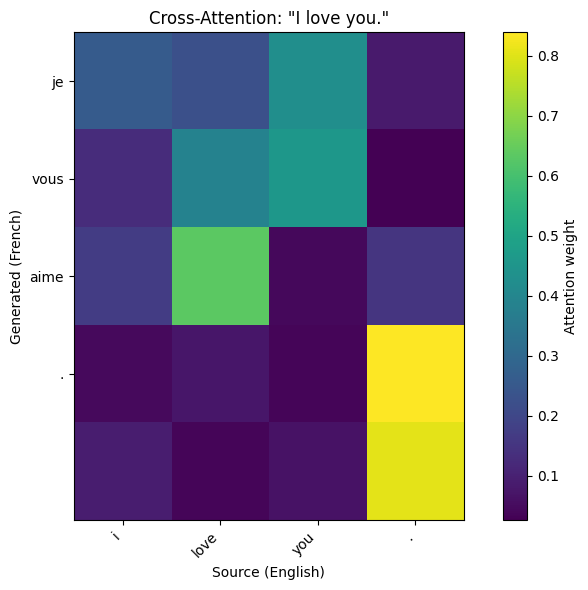

In [63]:
src_tokens = preprocess(sentence).split()
trg_tokens = [ids_to_text([t]) for t in out_ids]

plt.figure(figsize=(8, 6))
plt.imshow(attn_avg.numpy(), cmap="viridis")
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
plt.yticks(range(len(trg_tokens)), trg_tokens)
plt.xlabel("Source (English)")
plt.ylabel("Generated (French)")
plt.title(f'Cross-Attention: "{sentence}"')
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()

In [64]:
torch.save(model.state_dict(), "model_weights.pt")

with open("english_vocab.pkl", "wb") as f:
    pickle.dump(english_vocab, f)

with open("french_vocab.pkl", "wb") as f:
    pickle.dump(french_vocab, f)

print("Exported: model_weights.pt, english_vocab.pkl, french_vocab.pkl")

Exported: model_weights.pt, english_vocab.pkl, french_vocab.pkl
